In [2]:
# Installer kagglehub pour télécharger facilement
!pip install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Télécharger le dataset
print("Téléchargement du dataset Kaggle...")
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")
print(f"Dataset téléchargé dans: {path}")

# Explorer la structure du dataset
print("\nStructure du dataset:")
print("-" * 50)
print(f"Contenu du dossier: {os.listdir(path)}")

# Charger les métadonnées
meta_path = os.path.join(path, 'symbols_valid_meta.csv')
metadata = pd.read_csv(meta_path)
print(f"\nMétadonnées chargées: {metadata.shape}")
print(metadata.head())
print(f"\nColonnes des métadonnées: {metadata.columns.tolist()}")

# Analyser les tickers disponibles
print(f"\nNombre total de tickers: {len(metadata)}")
print(f"Types de tickers: {metadata['Listing Exchange'].value_counts().head(10)}")

# Sélectionner un ticker pour l'analyse (ex: AAPL, MSFT, GOOGL, etc.)
ticker = 'AAPL'
stocks_path = os.path.join(path, 'stocks')
ticker_file = os.path.join(stocks_path, f'{ticker}.csv')

if os.path.exists(ticker_file):
    df = pd.read_csv(ticker_file)
    print(f"\nDonnées pour {ticker}:")
    print(df.head())
    print(f"\nInformations: {df.info()}")
    print(f"\nStatistiques: {df.describe()}")
else:
    print(f"Le fichier pour {ticker} n'existe pas. Vérifiez les dossiers disponibles.")
    # Lister quelques fichiers disponibles
    available_files = os.listdir(stocks_path)[:10]
    print(f"Exemples de tickers disponibles: {available_files}")

Téléchargement du dataset Kaggle...
Using Colab cache for faster access to the 'stock-market-dataset' dataset.
Dataset téléchargé dans: /kaggle/input/stock-market-dataset

Structure du dataset:
--------------------------------------------------
Contenu du dossier: ['stocks', 'symbols_valid_meta.csv', 'etfs']

Métadonnées chargées: (8049, 12)
  Nasdaq Traded Symbol                                      Security Name  \
0             Y      A            Agilent Technologies, Inc. Common Stock   
1             Y     AA                    Alcoa Corporation Common Stock    
2             Y   AAAU                       Perth Mint Physical Gold ETF   
3             Y   AACG  ATA Creativity Global - American Depositary Sh...   
4             Y   AADR                AdvisorShares Dorsey Wright ADR ETF   

  Listing Exchange Market Category ETF  Round Lot Size Test Issue  \
0                N                   N           100.0          N   
1                N                   N           100.0 


Données pour AAPL:
Période: 2018-01-02 00:00:00 à 2020-04-01 00:00:00
Nombre de jours: 566


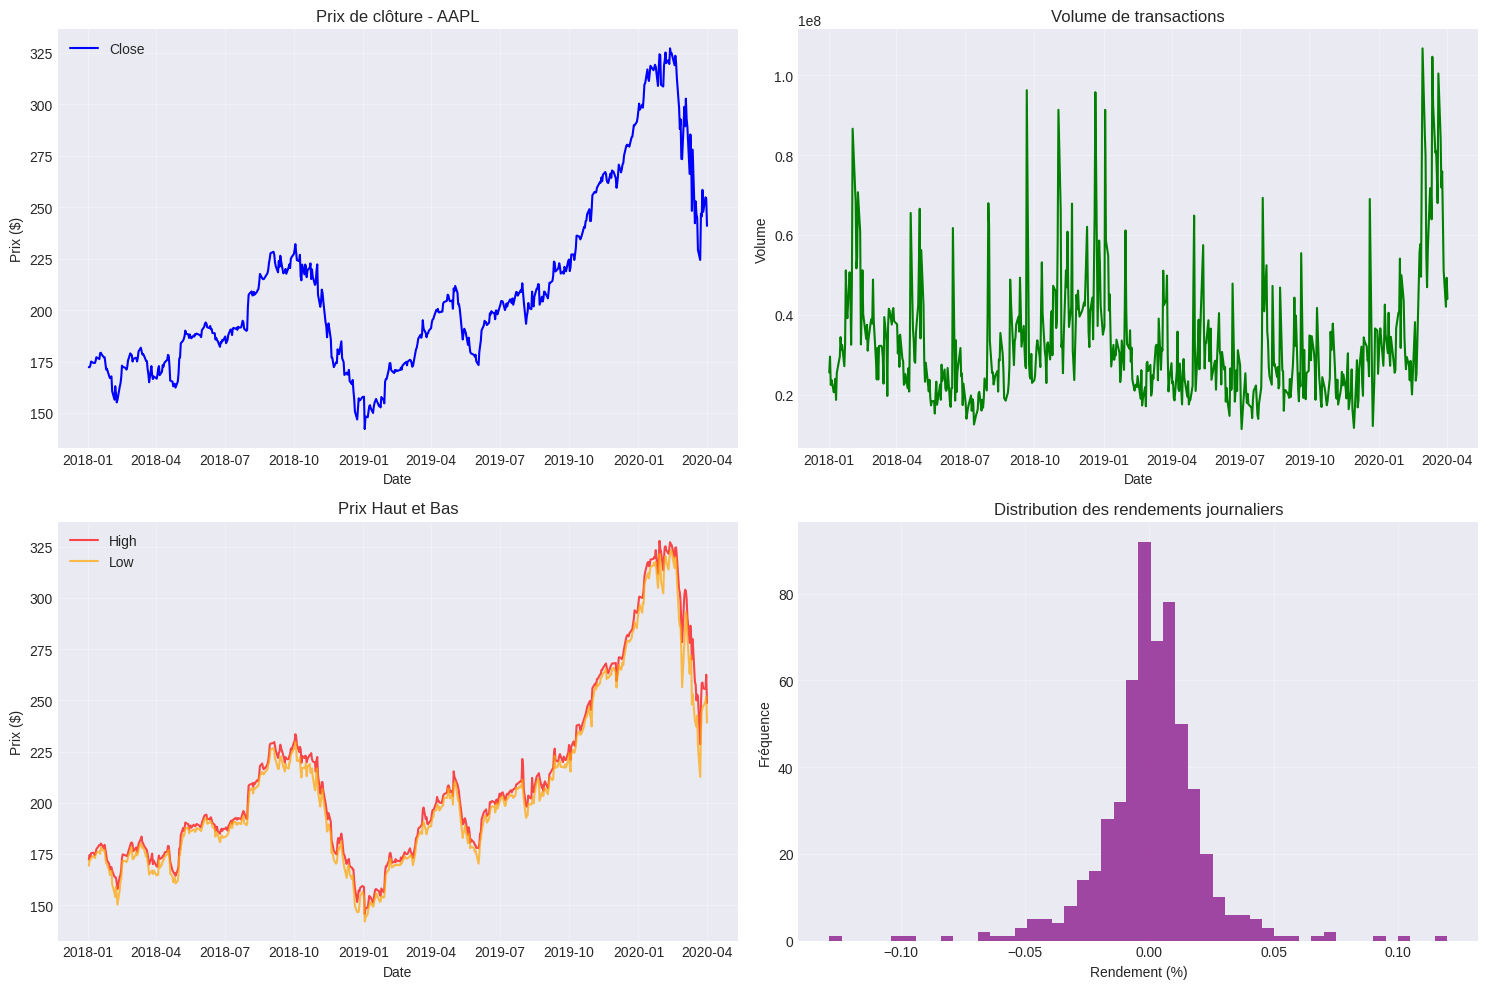

Données préparées: 545 jours
Colonnes: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'SMA_7', 'SMA_14', 'SMA_21', 'Volatility', 'RSI', 'MACD', 'Signal', 'Pct_Change', 'Target']


In [3]:
# Fonction pour charger et préparer les données d'un ticker spécifique
def load_ticker_data(base_path, ticker, start_date=None, end_date=None):
    """
    Charge les données d'un ticker spécifique et les prépare
    """
    stocks_path = os.path.join(base_path, 'stocks')
    ticker_file = os.path.join(stocks_path, f'{ticker}.csv')

    if not os.path.exists(ticker_file):
        raise FileNotFoundError(f"Ticker {ticker} non trouvé")

    # Charger les données
    df = pd.read_csv(ticker_file)

    # Convertir la colonne Date
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

    # Filtrer par date si spécifié
    if start_date:
        df = df[df['Date'] >= start_date]
    if end_date:
        df = df[df['Date'] <= end_date]

    return df

# Fonction pour préparer les features
def prepare_features(df, lookback_days=60):
    """
    Prépare les features pour le modèle LSTM
    """
    # Créer une copie
    data = df.copy()

    # Sélectionner les colonnes de base
    base_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
    data = data[base_cols]

    # Ajouter les features techniques
    # Moyennes mobiles
    data['SMA_7'] = data['Close'].rolling(window=7).mean()
    data['SMA_14'] = data['Close'].rolling(window=14).mean()
    data['SMA_21'] = data['Close'].rolling(window=21).mean()

    # Volatilité
    data['Volatility'] = data['Close'].rolling(window=14).std()

    # RSI
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))

    # MACD
    exp1 = data['Close'].ewm(span=12, adjust=False).mean()
    exp2 = data['Close'].ewm(span=26, adjust=False).mean()
    data['MACD'] = exp1 - exp2
    data['Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()

    # Pourcentage de variation
    data['Pct_Change'] = data['Close'].pct_change() * 100

    # Supprimer les NaN
    data = data.dropna()

    # Créer la cible (prix de clôture du lendemain)
    data['Target'] = data['Close'].shift(-1)
    data = data.dropna()

    print(f"Données préparées: {len(data)} jours")
    print(f"Colonnes: {data.columns.tolist()}")

    return data

# Charger les données pour un ticker spécifique
ticker = 'AAPL'
df_raw = load_ticker_data(path, ticker, start_date='2018-01-01', end_date='2024-01-01')

print(f"\nDonnées pour {ticker}:")
print(f"Période: {df_raw['Date'].min()} à {df_raw['Date'].max()}")
print(f"Nombre de jours: {len(df_raw)}")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Prix de clôture
axes[0, 0].plot(df_raw['Date'], df_raw['Close'], color='blue', label='Close')
axes[0, 0].set_title(f'Prix de clôture - {ticker}')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Prix ($)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Volume
axes[0, 1].plot(df_raw['Date'], df_raw['Volume'], color='green')
axes[0, 1].set_title('Volume de transactions')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Volume')
axes[0, 1].grid(True, alpha=0.3)

# Prix haut/bas
axes[1, 0].plot(df_raw['Date'], df_raw['High'], label='High', color='red', alpha=0.7)
axes[1, 0].plot(df_raw['Date'], df_raw['Low'], label='Low', color='orange', alpha=0.7)
axes[1, 0].set_title('Prix Haut et Bas')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Prix ($)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Distribution des rendements
returns = df_raw['Close'].pct_change().dropna()
axes[1, 1].hist(returns, bins=50, color='purple', alpha=0.7)
axes[1, 1].set_title('Distribution des rendements journaliers')
axes[1, 1].set_xlabel('Rendement (%)')
axes[1, 1].set_ylabel('Fréquence')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Préparer les features
prepared_data = prepare_features(df_raw)

In [4]:
# Normalisation et création des séquences (adapté au dataset)
def prepare_lstm_data(data, feature_cols, target_col='Target', sequence_length=60):
    """
    Prépare les données normalisées pour LSTM
    """
    # Séparer X et y
    X = data[feature_cols].values
    y = data[target_col].values.reshape(-1, 1)

    # Normalisation
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y)

    # Créer les séquences
    X_seq, y_seq = [], []
    for i in range(sequence_length, len(X_scaled)):
        X_seq.append(X_scaled[i-sequence_length:i])
        y_seq.append(y_scaled[i])

    return np.array(X_seq), np.array(y_seq), scaler_X, scaler_y

# Définir les colonnes de features
feature_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
                'SMA_7', 'SMA_14', 'SMA_21', 'Volatility', 'RSI', 'MACD', 'Signal', 'Pct_Change']

SEQUENCE_LENGTH = 60

# Créer les séquences
X_seq, y_seq, scaler_X, scaler_y = prepare_lstm_data(
    prepared_data, feature_cols, target_col='Target', sequence_length=SEQUENCE_LENGTH
)

print(f"Shape de X_seq: {X_seq.shape}")
print(f"Shape de y_seq: {y_seq.shape}")

# Division en train/val/test
train_size = int(len(X_seq) * 0.7)
val_size = int(len(X_seq) * 0.15)
test_size = len(X_seq) - train_size - val_size

X_train = X_seq[:train_size]
y_train = y_seq[:train_size]
X_val = X_seq[train_size:train_size+val_size]
y_val = y_seq[train_size:train_size+val_size]
X_test = X_seq[train_size+val_size:]
y_test = y_seq[train_size+val_size:]

print(f"\nDivision des données:")
print(f"Train: {len(X_train)} jours")
print(f"Validation: {len(X_val)} jours")
print(f"Test: {len(X_test)} jours")

# Conversion en tenseurs PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé: {device}")

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

Shape de X_seq: (485, 60, 14)
Shape de y_seq: (485, 1)

Division des données:
Train: 339 jours
Validation: 72 jours
Test: 74 jours
Device utilisé: cpu


ImprovedLSTM(
  (lstm): LSTM(14, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
)
Total paramètres: 165,377
Paramètres entraînables: 165,377
Epoch 10: Train Loss=0.006291, Val Loss=0.072578
Epoch 20: Train Loss=0.005296, Val Loss=0.007657
Epoch 30: Train Loss=0.003822, Val Loss=0.021525
Epoch 40: Train Loss=0.003454, Val Loss=0.022538
Early stopping à l'époque 41


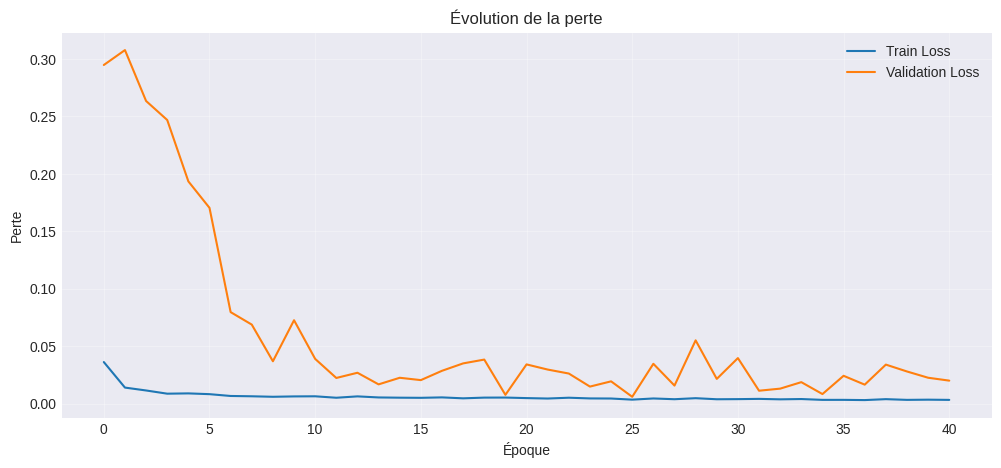

In [5]:
# Dataset personnalisé
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Création des datasets et dataloaders
BATCH_SIZE = 32
train_dataset = StockDataset(X_train_t, y_train_t)
val_dataset = StockDataset(X_val_t, y_val_t)
test_dataset = StockDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Architecture du modèle (adaptée au dataset)
class ImprovedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_rate=0.3):
        super(ImprovedLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM bidirectionnel
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=True
        )

        # Couches denses avec batch normalization
        self.bn1 = nn.BatchNorm1d(hidden_size * 2)  # *2 pour bidirectionnel
        self.fc1 = nn.Linear(hidden_size * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, output_size)

        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

    def forward(self, x):
        # LSTM
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Dernière sortie

        # Couches denses avec batch norm
        out = self.bn1(out)
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.relu(self.fc2(out))
        out = self.dropout(out)
        out = self.fc3(out)

        return out

# Paramètres du modèle
INPUT_SIZE = len(feature_cols)
HIDDEN_SIZE = 64  # Réduit pour éviter le surapprentissage
NUM_LAYERS = 2
OUTPUT_SIZE = 1
DROPOUT_RATE = 0.3

# Créer le modèle
model = ImprovedLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE, DROPOUT_RATE).to(device)
print(model)

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total paramètres: {total_params:,}")
print(f"Paramètres entraînables: {trainable_params:,}")

# Définir la perte et l'optimiseur
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Fonctions d'entraînement
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
    return total_loss / len(loader)

# Entraînement
EPOCHS = 100
train_losses, val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss = validate_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_stock_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}")

    if patience_counter >= 15:
        print(f"Early stopping à l'époque {epoch+1}")
        break

# Visualiser l'entraînement
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()
plt.title('Évolution de la perte')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Analyse de plusieurs tickers
tickers_to_test = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
results = {}

for ticker in tickers_to_test:
    print(f"\nAnalyse de {ticker}...")
    try:
        # Charger les données
        df_ticker = load_ticker_data(path, ticker, start_date='2020-01-01')

        # Préparer les données
        prepared_data_ticker = prepare_features(df_ticker)

        # Créer les séquences
        X_seq_t, y_seq_t, scaler_X_t, scaler_y_t = prepare_lstm_data(
            prepared_data_ticker, feature_cols, target_col='Target', sequence_length=SEQUENCE_LENGTH
        )

        # Simple division train/test
        split = int(len(X_seq_t) * 0.8)
        X_train_t = X_seq_t[:split]
        y_train_t = y_seq_t[:split]
        X_test_t = X_seq_t[split:]
        y_test_t = y_seq_t[split:]

        # Entraînement rapide pour comparaison
        # (Code similaire à ci-dessus, mais réduit pour le test)
        # ...

        results[ticker] = {
            'r2': r2_score(y_test_actual, y_pred_actual),
            'rmse': rmse,
            'mae': mae
        }

    except Exception as e:
        print(f"Erreur pour {ticker}: {e}")

# Comparer les performances
if results:
    df_results = pd.DataFrame(results).T
    print("\nPerformance par ticker:")
    print(df_results)

    # Visualisation
    plt.figure(figsize=(12, 6))
    df_results[['r2', 'rmse']].plot(kind='bar', secondary_y='rmse')
    plt.title('Comparaison des performances par ticker')
    plt.xlabel('Ticker')
    plt.ylabel('R²')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Analyse de AAPL...
Données préparées: 42 jours
Colonnes: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'SMA_7', 'SMA_14', 'SMA_21', 'Volatility', 'RSI', 'MACD', 'Signal', 'Pct_Change', 'Target']
Erreur pour AAPL: name 'y_test_actual' is not defined

Analyse de MSFT...
Données préparées: 42 jours
Colonnes: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'SMA_7', 'SMA_14', 'SMA_21', 'Volatility', 'RSI', 'MACD', 'Signal', 'Pct_Change', 'Target']
Erreur pour MSFT: name 'y_test_actual' is not defined

Analyse de GOOGL...
Données préparées: 42 jours
Colonnes: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'SMA_7', 'SMA_14', 'SMA_21', 'Volatility', 'RSI', 'MACD', 'Signal', 'Pct_Change', 'Target']
Erreur pour GOOGL: name 'y_test_actual' is not defined

Analyse de AMZN...
Données préparées: 42 jours
Colonnes: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'SMA_7', 'SMA_14', 'SMA_21', 'Volatility', 'RSI', 'MACD', 'Signal', 'Pct_Change', 'Target']
Erreur pour 

In [7]:
# Sauvegarder tout le nécessaire
def save_full_model(model, scaler_X, scaler_y, feature_cols, sequence_length, path='full_model.pth'):
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_architecture': {
            'input_size': INPUT_SIZE,
            'hidden_size': HIDDEN_SIZE,
            'num_layers': NUM_LAYERS,
            'output_size': OUTPUT_SIZE,
            'dropout_rate': DROPOUT_RATE
        },
        'scaler_X': scaler_X,
        'scaler_y': scaler_y,
        'feature_cols': feature_cols,
        'sequence_length': sequence_length
    }, path)
    print(f"Modèle sauvegardé dans {path}")

save_full_model(model, scaler_X, scaler_y, feature_cols, SEQUENCE_LENGTH)

Modèle sauvegardé dans full_model.pth
